
# Weather Analysis

---

## Project Overview

**This project serves as a hands-on introduction to *data engineering* and *machine learning* workflows.**  

It covers the full cycle:  
1. Data collection via [OpenWeatherMap API](https://openweathermap.org/api)

2. Data cleaning and storage in CSV format

3. Exploratory analysis and visualization



---

### External libs

The following Python libraries are required to run this notebook. They cover API requests, data manipulation, visualization, and working with raw JSON responses.

- **requests** — sending HTTP requests to the OpenWeatherMap API
- **pandas** — data manipulation and CSV export
- **datetime** — timestamp generation for collected data
- **json** — parsing and inspecting raw API responses
- **matplotlib** — creating charts and visualizations for data analysis

In [67]:
import requests as rq
import pandas as pd
import datetime as dt
import json
import matplotlib.pyplot as plt #for visualisation

---

### API Key Security

The OpenWeatherMap API key is stored locally in `data/API_key.txt` and is **not shared** in this repository. The file is excluded via `.gitignore`.

To use this notebook with your own key:

1. Sign up at [openweathermap.org](https://openweathermap.org) and generate a free API key

2. Create a file `data/API_key.txt` in the project folder

3. Paste your key into the file as a single line — no quotes, no spaces

In [68]:
with open("data/API_key.txt", "r") as file:
    WEATHER_API_KEY = file.read().strip()

---

## API Request, Data Transformation & CSV Export

This section performs a single API call to OpenWeatherMap, extracts the relevant weather fields from the JSON response, transforms them into a structured tabular format using Pandas, and appends the result to a local CSV file for future accumulation.

**Workflow:**

1. Send a GET request to the OpenWeatherMap `/weather`

2. Parse the returned JSON and select only the fields relevant for analysis

3. Convert the extracted data into a Pandas DataFrame

4. Write this data to `data/dataset.csv`

In [69]:
import time #for delay

with open("data/cities.txt") as file:
    cities = [line.strip() for line in file]
url = f"http://api.openweathermap.org/data/2.5/weather"
params = {"q" : "",
          "appid" : WEATHER_API_KEY,
          "units" : "metric"}
records = []
for city in cities:
    #Sending our GET request
    params["q"] = city
    response = rq.get(url, params=params)
    if response.status_code == 200:
        #Transforming data to JSON
        data = response.json()
    
        weather_record = {
            'city': city,
            'country': data['sys']['country'],
            'lon': data['coord']['lon'],
            'lat': data['coord']['lat'],
            'temp': data['main']['temp'],
            'feels_like': data['main']['feels_like'],
            'temp_min': data['main']['temp_min'],
            'temp_max': data['main']['temp_max'],
            'pressure': data['main']['pressure'],
            'humidity': data['main']['humidity'],
            'sea_level': data['main'].get('sea_level', None),
            'grnd_level': data['main'].get('grnd_level', None),
            'visibility': data.get('visibility', None),
            'wind_speed': data['wind']['speed'],
            'wind_deg': data['wind']['deg'],
            'wind_gust': data['wind'].get('gust', None),
            'clouds': data['clouds']['all'],
            'weather_main': data['weather'][0]['main'],
            'weather_description': data['weather'][0]['description'],
            'weather_icon': data['weather'][0]['icon'],
            'timezone': data['timezone']
        }
        records.append(weather_record)
        time.sleep(1)
        
df = pd.DataFrame(records)
df.to_csv("data/dataset.csv", index=False)
print("Dataset created succesfuly")

Dataset created succesfuly


### Summary

The API request was successfully executed and the data pipeline performed as expected:

- **API Call:** A GET request was sent to the OpenWeatherMap `/weather` endpoint for each city listed in `data/cities.txt`.

- **Response Handling:** Each successful response (HTTP 200) was parsed, and 21 relevant weather fields were extracted from the JSON structure.

- **Data Transformation:** The extracted records were accumulated into a list of dictionaries and converted into a Pandas DataFrame with each row representing one city.

- **Data Export:** The resulting DataFrame was saved to `data/dataset.csv` without the index column, making it ready for further analysis or accumulation in future runs.

- **Rate Limiting:** A 1-second delay was added between requests to respect API rate limits.

**Output Structure:** The final dataset contains one row per city with columns for geographical coordinates, temperature metrics, atmospheric conditions, wind data, cloud coverage, and weather descriptions.

---

## Exploratory Data Analysis (EDA)

This section explores the collected weather snapshot for 150+ cities worldwide.  

The goal is to identify trends, extremes, and patterns in the data before any modeling.

**What we investigate:**
- **Summary** statistics for all numerical features

- Missing values across columns

- **Top-10** hottest and coldest cities

- Cities with the largest gap between actual and perceived temperature (temp vs feels_like)

- Windiest, most humid, and clearest cities

- Distribution of **temperature** across the dataset (histogram)

- Relationship between **temperature** and **humidity** (scatter plot)

### 1.1 Summary Statistics & Missing Values

First, we **generate descriptive statistics** for all numerical columns and check for missing values.

This helps us understand the range, central tendency, and completeness of the dataset.

- Top 5 records from our dataset

In [70]:
df.head()

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone
0,Moscow,RU,37.6156,55.7522,17.43,16.72,17.43,17.43,1005,57,...,986,10000,2.24,311,2.61,94,Clouds,overcast clouds,04d,10800
1,Saint Petersburg,RU,30.2642,59.8944,19.47,19.09,19.47,19.47,1002,62,...,1000,10000,0.89,154,4.47,80,Clouds,broken clouds,04d,10800
2,Novosibirsk,RU,82.9344,55.0411,26.34,26.34,26.34,26.34,1006,54,...,987,10000,0.43,358,0.96,9,Clear,clear sky,01d,25200
3,Yekaterinburg,RU,60.6125,56.8575,18.83,19.04,18.83,18.83,1004,87,...,971,10000,2.13,86,4.01,99,Rain,moderate rain,10d,18000
4,Kazan,RU,49.1221,55.7887,25.17,25.00,25.17,25.17,1003,48,...,990,10000,3.05,95,2.85,42,Clouds,scattered clouds,03d,10800


- General information

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 194 non-null    str    
 1   country              194 non-null    str    
 2   lon                  194 non-null    float64
 3   lat                  194 non-null    float64
 4   temp                 194 non-null    float64
 5   feels_like           194 non-null    float64
 6   temp_min             194 non-null    float64
 7   temp_max             194 non-null    float64
 8   pressure             194 non-null    int64  
 9   humidity             194 non-null    int64  
 10  sea_level            194 non-null    int64  
 11  grnd_level           194 non-null    int64  
 12  visibility           194 non-null    int64  
 13  wind_speed           194 non-null    float64
 14  wind_deg             194 non-null    int64  
 15  wind_gust            188 non-null    float64
 16  c

- Basic descriptive statistics

In [72]:
df.describe()

,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,sea_level,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds,timezone
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,188.000000,194.000000,194.000000
mean,30.767630,29.123993,23.203608,23.742423,22.813144,23.617526,1010.443299,63.546392,1010.443299,974.731959,9915.860825,3.267216,203.448454,4.767713,58.262887,9830.412371
std,72.221091,26.010596,7.791544,8.839426,7.946844,7.708626,7.318044,21.383263,7.318044,64.045242,538.043063,2.195188,97.710262,3.096957,37.680247,16535.875673
min,-123.119300,-43.533300,3.500000,3.500000,2.220000,3.860000,997.000000,5.000000,997.000000,622.000000,5075.000000,0.280000,0.000000,0.450000,0.000000,-25200.000000
25%,-0.179100,17.523150,17.192500,16.992500,16.380000,17.732500,1005.000000,51.000000,1005.000000,979.250000,10000.000000,1.377500,127.500000,2.680000,22.500000,3600.000000
50%,37.216150,35.435500,23.330000,23.605000,23.065000,23.630000,1010.000000,68.000000,1010.000000,997.000000,10000.000000,2.725000,214.500000,4.255000,66.500000,10800.000000
75%,78.256625,48.190725,28.520000,29.835000,28.175000,28.822500,1015.000000,79.750000,1015.000000,1008.000000,10000.000000,4.530000,285.750000,6.342500,94.750000,19800.000000
max,178.441500,68.000000,43.580000,42.610000,43.580000,43.580000,1032.000000,100.000000,1032.000000,1027.000000,10000.000000,10.730000,360.000000,24.140000,100.000000,43200.000000


- find columns with **Null** values

In [73]:
missing = df.isnull().sum()
print(missing[missing > 0])

wind_gust    6
dtype: int64


- Records with **Null** values

In [74]:
df[df.isnull().any(axis=1)]

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone
22,Berlin,DE,13.4105,52.5244,16.40,15.98,13.38,18.34,1008,72,...,1003,10000,8.05,270,NaN,97,Rain,moderate rain,10d,7200
28,Prague,CZ,14.4208,50.0880,16.10,15.28,14.93,17.51,1013,58,...,978,10000,5.36,280,NaN,84,Clouds,broken clouds,04d,7200
49,Hong Kong,HK,114.1577,22.2855,29.49,36.49,28.60,30.21,1006,82,...,1001,5075,7.15,210,NaN,100,Clouds,overcast clouds,04n,28800
80,Casablanca,MA,-7.6192,33.5928,24.07,24.10,24.07,24.07,1018,60,...,1009,10000,2.68,340,NaN,31,Clouds,scattered clouds,03d,3600
97,Tehran,IR,51.4215,35.6944,33.73,31.22,33.73,33.73,1003,9,...,857,10000,4.02,280,NaN,0,Clear,clear sky,01d,12600
171,Pune,IN,73.8553,18.5196,33.24,32.15,32.45,34.21,1008,29,...,936,10000,2.24,262,NaN,0,Clear,clear sky,01d,19800


- Descriptive statistics for `wind_gust` and **hist**

In [75]:
df.wind_gust.describe()

count    188.000000
mean       4.767713
std        3.096957
min        0.450000
25%        2.680000
50%        4.255000
75%        6.342500
max       24.140000
Name: wind_gust, dtype: float64

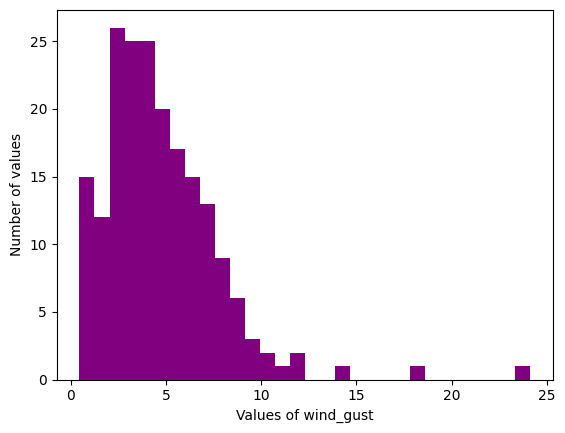

In [90]:
plt.hist(df["wind_gust"], color="purple", bins=30)
plt.xlabel("Values of wind_gust")
plt.ylabel("Number of values");

- replace **Null** with median and build **hist** again

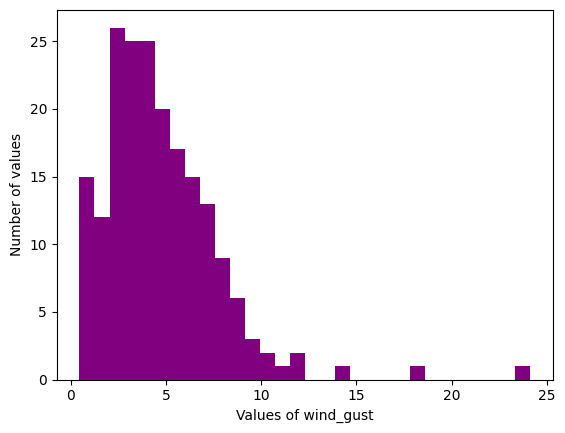

In [91]:
df["wind_gust"] = df["wind_gust"].fillna(df["wind_gust"].median())
plt.hist(df["wind_gust"], color="purple", bins=30)
plt.xlabel("Values of wind_gust")
plt.ylabel("Number of values");

- Result - replaced wind_gust in 6 recordings to `wind_gust.median()`

### 1.2 Top-10 Hottest and Coldest Cities

We identify the cities with the **highest** and **lowest** recorded *temperatures* in the dataset.

This gives a quick snapshot of the current weather extremes across the globe.

- **Hottest cities**

In [78]:
df.sort_values("temp", ascending=False).head(10)

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone
92,Riyadh,SA,46.7219,24.6877,43.58,39.13,43.58,43.58,1002,5,...,933,10000,2.70,266,3.65,0,Clear,clear sky,01d,10800
101,Delhi,IN,77.2167,28.6667,41.34,40.61,41.34,41.34,997,18,...,973,10000,4.31,303,7.37,0,Clear,clear sky,01d,19800
98,Baghdad,IQ,44.4009,33.3406,40.38,37.56,40.38,40.38,1002,11,...,998,10000,7.88,267,10.01,0,Clear,clear sky,01d,10800
174,Lucknow,IN,80.9167,26.8500,40.10,38.38,40.10,40.10,997,16,...,983,10000,6.08,299,7.12,0,Clear,clear sky,01d,19800
106,Lahore,PK,74.3436,31.5497,39.71,38.97,39.71,39.71,998,20,...,975,10000,2.63,355,3.43,0,Clear,clear sky,01d,18000
91,Doha,QA,51.5333,25.2867,39.69,40.94,39.69,39.69,1001,26,...,1000,10000,7.16,33,8.57,4,Clear,clear sky,01d,10800
172,Ahmedabad,IN,72.6167,23.0333,39.39,40.43,39.39,39.39,1002,26,...,997,10000,7.41,287,7.86,0,Clear,clear sky,01d,19800
177,Tashkent,UZ,69.2163,41.2646,37.34,34.74,37.34,37.34,1002,13,...,955,10000,2.31,252,3.13,100,Clouds,overcast clouds,04d,18000
165,Kuwait City,KW,47.9783,29.3697,37.10,39.53,37.10,37.10,1001,35,...,999,10000,5.44,110,4.78,0,Clear,clear sky,01d,10800
94,Muscat,OM,58.5922,23.6139,36.29,40.48,36.29,36.29,1001,42,...,992,10000,1.61,52,2.86,0,Clear,clear sky,01d,14400


- **Coldest cities**

In [79]:
df.sort_values("temp", ascending=False).tail(10)

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone
162,Christchurch,NZ,172.6333,-43.5333,9.97,8.29,9.97,9.97,1018,69,...,1011,10000,3.33,21,5.38,0,Clear,clear sky,01n,43200
110,Murmansk,RU,34.0000,68.0000,9.69,6.64,9.69,9.69,1014,68,...,982,10000,6.68,69,9.72,100,Clouds,overcast clouds,04n,10800
191,Nuuk,GL,-51.7216,64.1835,9.14,8.22,9.14,9.14,1017,61,...,1015,10000,1.97,84,2.78,0,Clear,clear sky,01d,-3600
154,Sucre,BO,-65.2627,-19.0333,8.85,8.16,8.85,8.85,1021,77,...,732,10000,1.67,16,2.03,68,Clouds,broken clouds,04d,-14400
73,Montevideo,UY,-56.1674,-34.8335,8.74,6.25,8.74,8.74,1023,73,...,1020,10000,4.45,202,6.15,40,Clouds,scattered clouds,03d,-10800
72,Quito,EC,-78.5249,-0.2299,8.44,7.33,8.44,8.44,1020,79,...,724,10000,2.05,135,2.88,67,Clouds,broken clouds,04d,-18000
63,Calgary,CA,-114.0853,51.0501,7.67,7.19,6.90,9.31,1024,77,...,897,10000,1.34,238,2.68,39,Clouds,scattered clouds,03d,-21600
116,Petropavlovsk-Kamchatsky,RU,158.6483,53.0452,6.29,6.29,6.29,6.29,1024,94,...,1007,10000,1.18,127,1.42,60,Clouds,broken clouds,04n,43200
74,La Paz,BO,-68.1500,-16.5000,5.33,4.40,5.33,5.33,1023,43,...,622,10000,1.44,30,1.43,6,Clear,clear sky,01d,-14400
67,Buenos Aires,AR,-58.3772,-34.6132,3.50,3.50,2.22,3.86,1025,81,...,1024,10000,0.45,158,0.89,0,Clear,clear sky,01d,-10800


### 1.3 Temperature vs Feels Like Gap

We calculate the difference between perceived temperature (`feels_like`) and actual temperature (`temp`).

A large **positive** gap means the heat feels worse due to high humidity.

A large **negative** gap means wind makes it feel much colder than the thermometer shows.

In [80]:
df["feels_like_diff"] = abs(df["feels_like"] - df["temp"])
df.sort_values("feels_like_diff", ascending=False).head()

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,visibility,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone,feels_like_diff
49,Hong Kong,HK,114.1577,22.2855,29.49,36.49,28.60,30.21,1006,82,...,5075,7.15,210,4.255,100,Clouds,overcast clouds,04n,28800,7.0
100,Mumbai,IN,72.8479,19.0144,31.11,38.11,31.11,31.11,1007,71,...,10000,7.60,275,8.160,47,Clouds,scattered clouds,03d,19800,7.0
53,Manila,PH,120.9822,14.6042,30.07,37.07,30.06,30.07,1010,86,...,10000,3.99,222,4.680,58,Clouds,broken clouds,04n,28800,7.0
90,Dubai,AE,55.3047,25.2582,33.53,40.53,33.53,33.53,1001,60,...,10000,5.52,340,5.520,0,Clear,clear sky,01d,14400,7.0
42,Shenzhen,CN,114.0683,22.5455,29.72,36.72,28.54,30.15,1006,90,...,9506,3.97,216,7.360,100,Rain,light rain,10n,28800,7.0


### 1.4 Windiest, Most Humid, and Clearest Cities

We identify the cities with the most extreme values for **wind speed**, **humidity**, and **cloud cover**.

In [81]:
print("Windiest:")
print(df.loc[df["wind_speed"].idxmax()].city)
print("\nMost_humid:")
print(df.loc[df["humidity"].idxmax()].city)
print("\nClearest:")
print(df.loc[df["clouds"].idxmin()].city)

Windiest:
Wellington

Most_humid:
Rio de Janeiro

Clearest:
Athens


### 1.5 Temperature Distribution

A **histogram** of temperature across all 200 cities to see the overall spread.

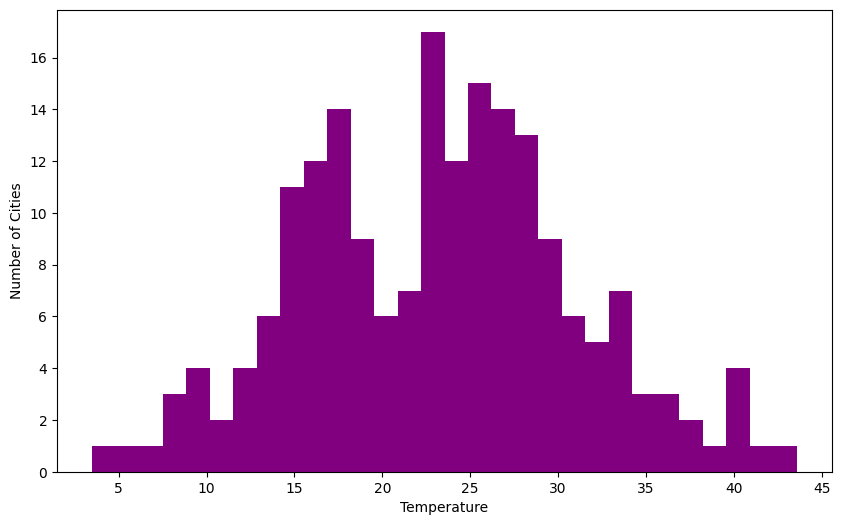

In [82]:
plt.figure(figsize=(10,6))
plt.hist(df["temp"], bins=30, linewidth=0.5, color='purple')
plt.xlabel("Temperature")
plt.ylabel("Number of Cities");

### 1.6 Temperature vs Humidity

A **scatter plot** to explore the relationship between `temperature` and `humidity` across all cities.

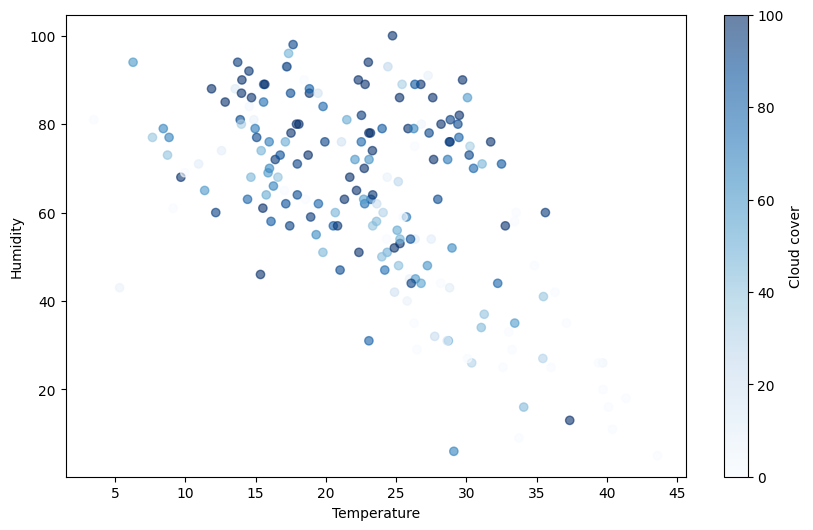

In [83]:
plt.figure(figsize=(10,6))
plt.scatter(df["temp"], df["humidity"], c=df["clouds"], cmap="Blues", alpha=0.6)
plt.colorbar(label="Cloud cover")
plt.xlabel("Temperature")
plt.ylabel("Humidity");

---

## 2. Comfort Index

We design a custom metric to rank cities by how pleasant their current weather feels.

The index penalizes deviations from an ideal temperature (22°C), ideal humidity (50%), high wind speed, and high cloud cover.

**Formula:**

$$
\text{Comfort} = 100 - 2.0 \cdot \left| \frac{T + F}{2} - 22 \right| - 0.3 \cdot |H - 50| - 1.5 \cdot W - 0.2 \cdot C
$$

Where:
- $T$ = temperature (°C)
- $F$ = feels_like (°C)
- $H$ = humidity (%)
- $W$ = wind speed (m/s)
- $C$ = cloud cover (%)

**Higher score** = more comfortable city right now.

In [87]:
df["comfort_score"] = (100
                       - abs((df["temp"] + df["feels_like"]) / 2 - 22) * 2
                       - abs(df["humidity"] - 50) * 0.3
                       - df["wind_speed"] * 1.5
                       - df["clouds"] * 0.2)

#### 10 Most comfortable today

In [88]:
df.sort_values("comfort_score", ascending=False).head()

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone,feels_like_diff,comfort_score
95,Istanbul,TR,28.9833,41.0351,24.32,24.22,23.53,27.77,1015,54,...,1.03,236,3.20,0,Clear,clear sky,01d,10800,0.10,92.715
2,Novosibirsk,RU,82.9344,55.0411,26.34,26.34,26.34,26.34,1006,54,...,0.43,358,0.96,9,Clear,clear sky,01d,25200,0.00,87.675
78,Johannesburg,ZA,28.0436,-26.2023,18.57,18.13,17.08,18.80,1022,63,...,0.89,54,2.68,0,Clear,clear sky,01d,7200,0.44,87.465
132,Busan,KR,129.0403,35.1028,21.11,21.26,21.11,21.11,1012,76,...,0.87,170,0.93,19,Clouds,few clouds,02n,32400,0.15,85.465
11,Ufa,RU,56.0375,54.7750,23.98,23.74,23.98,23.98,1002,50,...,1.55,64,1.70,43,Clouds,scattered clouds,03d,18000,0.24,85.355


#### 10 Least comfortable cities

In [89]:
df.sort_values("comfort_score", ascending=False).tail()

,city,country,lon,lat,temp,feels_like,temp_min,temp_max,pressure,humidity,...,wind_speed,wind_deg,wind_gust,clouds,weather_main,weather_description,weather_icon,timezone,feels_like_diff,comfort_score
42,Shenzhen,CN,114.0683,22.5455,29.72,36.72,28.54,30.15,1006,90,...,3.97,216,7.360,100,Rain,light rain,10n,28800,7.00,39.605
49,Hong Kong,HK,114.1577,22.2855,29.49,36.49,28.60,30.21,1006,82,...,7.15,210,4.255,100,Clouds,overcast clouds,04n,28800,7.00,37.695
177,Tashkent,UZ,69.2163,41.2646,37.34,34.74,37.34,37.34,1002,13,...,2.31,252,3.130,100,Clouds,overcast clouds,04d,18000,2.60,37.355
110,Murmansk,RU,34.0000,68.0000,9.69,6.64,9.69,9.69,1014,68,...,6.68,69,9.720,100,Clouds,overcast clouds,04n,10800,3.05,36.910
103,Chennai,IN,80.2785,13.0878,35.61,42.61,35.05,35.61,1005,60,...,4.55,106,5.320,96,Clouds,overcast clouds,04d,19800,7.00,36.755


The initial comfort index used raw temperature as the only thermal input.

While simple, this approach missed a critical dimension: the human body does not feel thermometer readings — it feels the combined effect of heat, humidity, and wind.

To address this, the formula was revised to use the average of actual temperature and the "feels like" value provided by the API:

- **Actual temperature** anchors the score in an objective physical measurement.

- **Feels like temperature** introduces a physiologically-aware correction that already accounts for wind chill and humidity.

- Averaging the two smooths out extreme discrepancies without double-counting penalties already present in the feels-like adjustment.

The result is a more robust and perceptually accurate comfort ranking. Cities with large gaps between actual and perceived temperature are now penalized appropriately, while those where the two values align receive a fairer evaluation.

---

## 3. Correlation Analysis

We examine targeted pairwise correlations to understand key relationships in the data.

The goal is to identify which factors most influence perceived temperature and comfort.

**Selected pairs:**

- `temp` vs `humidity` — how temperature relates to moisture in the air

- `feels_like_diff` vs `wind_speed` — does wind explain the gap between perception and reality?

- `feels_like_diff` vs `humidity` — does humidity explain that same gap?

### 3.1 Temperature vs Humidity

We start with the most intuitive relationship: as temperature rises, does humidity tend to drop?

A strong negative correlation here would confirm that hotter cities in our snapshot are generally drier.

- Calculate correlation

In [95]:
corr_temp_hum = df["temp"].corr(df["humidity"])
round(float(corr_temp_hum), 4)

-0.5831

- Build scatter plot

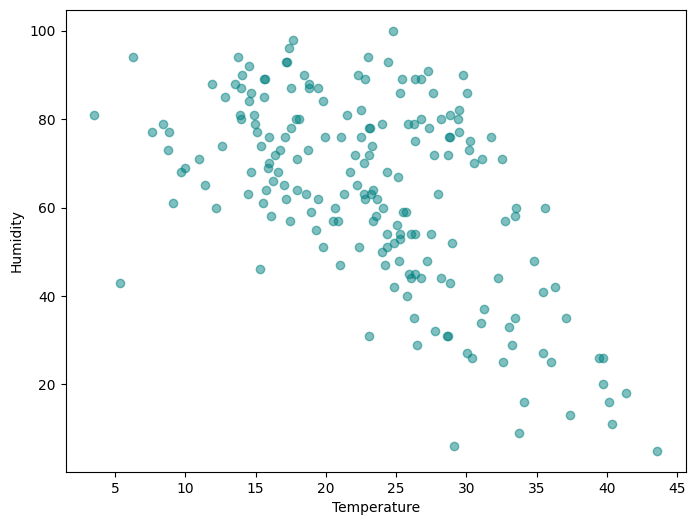

In [96]:
plt.figure(figsize=(8, 6))
plt.scatter(df["temp"], df["humidity"], alpha=0.5, color="teal")
plt.xlabel("Temperature")
plt.ylabel("Humidity");

**Finding:** The correlation is **-0.58**, confirming a moderate **negative relationship**.

In this snapshot, *hotter* cities tend to be *drier*. 

This aligns with physical intuition: warm air can hold more moisture, but actual humidity depends on geography and weather patterns.

The relationship is strong enough to be meaningful but not deterministic — humidity is influenced by other factors beyond temperature alone.

### 3.2 Feels Like Difference vs Wind Speed

Next, we test whether wind is responsible for the gap between actual and perceived temperature.

A strong negative correlation would confirm that windier cities feel colder than the thermometer suggests.

- Calculate correlation

In [97]:
corr_diff_wind = df["feels_like_diff"].corr(df["wind_speed"])
round(float(corr_diff_wind), 4)

0.2083

- Build scatter plot

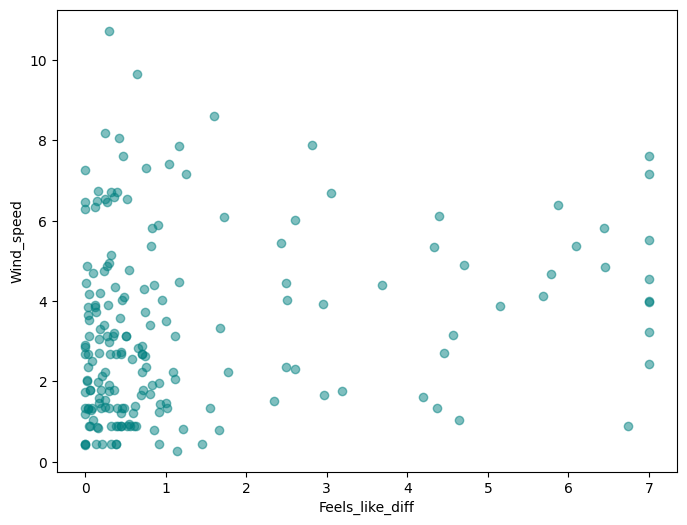

In [98]:
plt.figure(figsize=(8, 6))
plt.scatter(df["feels_like_diff"], df["wind_speed"], alpha=0.5, color="teal")
plt.xlabel("Feels_like_diff")
plt.ylabel("Wind_speed");

**Finding:** The correlation is only **0.21**, which is weak. 

Wind speed alone does not explain the gap between actual and perceived temperature.

This makes sense: the feels_like formula also incorporates humidity and temperature itself, so wind is just one piece of a more complex calculation.
 
For modeling, wind cannot be used alone to predict the feels_like deviation.

### 3.3 Feels Like Difference vs Humidity

Finally, we check whether humidity drives the gap between actual and perceived temperature.

A positive correlation would mean that more humid cities feel hotter than the thermometer shows.

- Calculate correlation

In [101]:
corr_diff_hum = df["feels_like_diff"].corr(df["humidity"])
round(float(corr_diff_hum))

0

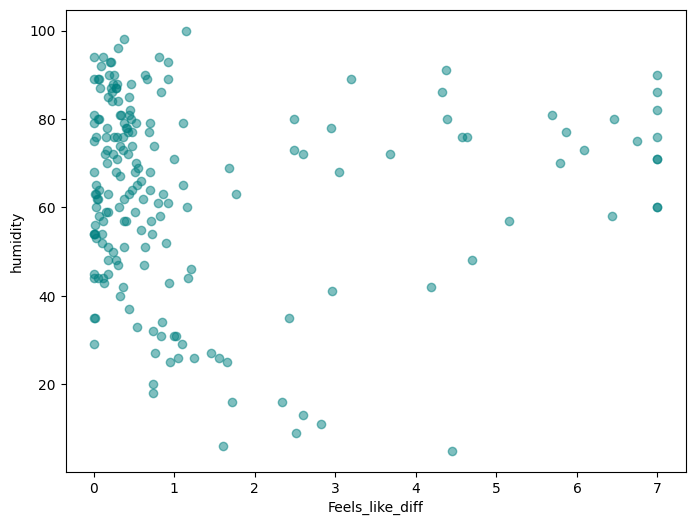

In [102]:
plt.figure(figsize=(8, 6))
plt.scatter(df["feels_like_diff"], df["humidity"], alpha=0.5, color="teal")
plt.xlabel("Feels_like_diff")
plt.ylabel("humidity");

**Finding:** The correlation is essentially **zero**. 

Humidity alone has no linear relationship with the feels-like gap in this dataset.

This confirms that `feels_like_diff` is not driven by a single variable — it emerges from the combination of temperature, humidity, 

wind, and their interactions inside the API's formula.

For future modeling, we should treat it as a composite target, not something explainable by one predictor.

---